# Import Libraries

In [1]:
import sys, os

# Add path to import
sys.path.append(os.path.abspath(".."))

In [2]:
from src.forecasting.utils.libraries_data_handling import pd, np
from src.forecasting.utils.libraries_others import re, os, time
from src.forecasting.utils.libraries_plotting import plt
from src.forecasting.utils.libraries_modelling import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from src.forecasting.constants.columns import col_decode, col_encode
from src.forecasting.constants.enums import ColumnGroup, PeriodList
from src.forecasting.constants.color import color_variant

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
/home/jovyan/work/3012010008/env_3012010008/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Backtesting Results

In [3]:
# Load TFT backtesting results
tft_backtesting = (
    pd.read_excel('../data/predicted/tft_backcast_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)

# Check
print(tft_backtesting.info())
pd.concat([
    tft_backtesting.head(3),
    pd.DataFrame(index=['...']),
    tft_backtesting.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2536 entries, 2025-03-17 08:00:00 to 2025-06-30 23:00:00
Freq: h
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   y1_actual  2536 non-null   float64
 1   y2_actual  2536 non-null   float64
 2   y3_actual  2536 non-null   int64  
 3   y4_actual  2536 non-null   float64
 4   y5_actual  2536 non-null   float64
 5   y1_pred    2536 non-null   float64
 6   y2_pred    2536 non-null   float64
 7   y3_pred    2536 non-null   float64
 8   y4_pred    2536 non-null   float64
 9   y5_pred    2536 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 217.9 KB
None


,y1_actual,y2_actual,y3_actual,y4_actual,y5_actual,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred
2025-03-17 08:00:00,44.7,44.8,1148.0,45.6,30.8,37.229717,40.733109,1465.548340,35.715729,21.234333
2025-03-17 09:00:00,36.2,36.3,867.0,32.8,39.6,27.745655,41.569767,950.114197,44.142376,23.669201
2025-03-17 10:00:00,36.4,36.8,635.0,22.0,44.4,44.695381,55.422333,824.539124,31.665188,26.053591
...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 23:00:00,19.0,20.5,558.0,20.5,8.6,22.031466,34.385120,1773.431763,41.200180,13.475987


In [4]:
# Load N-BEATS backtesting results
nbeats_backtesting = (
    pd.read_excel('../data/predicted/nbeats_backcast_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)

# Check
print(nbeats_backtesting.info())
pd.concat([
    nbeats_backtesting.head(3),
    pd.DataFrame(index=['...']),
    nbeats_backtesting.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2536 entries, 2025-03-17 08:00:00 to 2025-06-30 23:00:00
Freq: h
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   y1_actual  2536 non-null   float64
 1   y2_actual  2536 non-null   float64
 2   y3_actual  2536 non-null   int64  
 3   y4_actual  2536 non-null   float64
 4   y5_actual  2536 non-null   float64
 5   y1_pred    2536 non-null   float64
 6   y2_pred    2536 non-null   float64
 7   y3_pred    2536 non-null   float64
 8   y4_pred    2536 non-null   float64
 9   y5_pred    2536 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 217.9 KB
None


,y1_actual,y2_actual,y3_actual,y4_actual,y5_actual,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred
2025-03-17 08:00:00,44.7,44.8,1148.0,45.6,30.8,40.012341,49.425449,1231.157837,33.655975,27.537138
2025-03-17 09:00:00,36.2,36.3,867.0,32.8,39.6,38.096859,44.815575,1030.836304,33.866051,29.017538
2025-03-17 10:00:00,36.4,36.8,635.0,22.0,44.4,33.003246,40.376072,740.980835,31.763430,21.880522
...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 23:00:00,19.0,20.5,558.0,20.5,8.6,28.947666,33.623878,967.742737,27.531820,5.475500


# Calcute ISPU Backtesting

In [5]:
# Calculate last 24 hours mean every 1 hour
tft_rolling = (
    tft_backtesting
    .rolling(window=24)
    .mean()
)

# Check
print(tft_rolling.info())
pd.concat([
    tft_rolling.head(27),
    pd.DataFrame(index=['...']),
    tft_rolling.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2536 entries, 2025-03-17 08:00:00 to 2025-06-30 23:00:00
Freq: h
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   y1_actual  2513 non-null   float64
 1   y2_actual  2513 non-null   float64
 2   y3_actual  2513 non-null   float64
 3   y4_actual  2513 non-null   float64
 4   y5_actual  2513 non-null   float64
 5   y1_pred    2513 non-null   float64
 6   y2_pred    2513 non-null   float64
 7   y3_pred    2513 non-null   float64
 8   y4_pred    2513 non-null   float64
 9   y5_pred    2513 non-null   float64
dtypes: float64(10)
memory usage: 217.9 KB
None


,y1_actual,y2_actual,y3_actual,y4_actual,y5_actual,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred
2025-03-17 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Calculate last 24 hours mean every 1 hour
nbeats_rolling = (
    nbeats_backtesting
    .rolling(window=24)
    .mean()
)

# Check
print(nbeats_rolling.info())
pd.concat([
    nbeats_rolling.head(27),
    pd.DataFrame(index=['...']),
    nbeats_rolling.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2536 entries, 2025-03-17 08:00:00 to 2025-06-30 23:00:00
Freq: h
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   y1_actual  2513 non-null   float64
 1   y2_actual  2513 non-null   float64
 2   y3_actual  2513 non-null   float64
 3   y4_actual  2513 non-null   float64
 4   y5_actual  2513 non-null   float64
 5   y1_pred    2513 non-null   float64
 6   y2_pred    2513 non-null   float64
 7   y3_pred    2513 non-null   float64
 8   y4_pred    2513 non-null   float64
 9   y5_pred    2513 non-null   float64
dtypes: float64(10)
memory usage: 217.9 KB
None


,y1_actual,y2_actual,y3_actual,y4_actual,y5_actual,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred
2025-03-17 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Breakpoints rules for pollutant convertions to ISPU
breakpoints = {
    'y1': [  # PM2.5
        (0, 50, 0, 15.5),
        (51, 100, 15.5, 55.4),
        (101, 200, 55.4, 150.4),
        (201, 300, 150.4, 250.4),
        (301, 500, 250.4, 500)
    ],
    'y2': [  # PM10
        (0, 50, 0, 50),
        (51, 100, 50, 150),
        (101, 200, 150, 350),
        (201, 300, 350, 420),
        (301, 500, 420, 500)
    ],
    'y3': [  # CO
        (0, 50, 0, 4000),
        (51, 100, 4000, 8000),
        (101, 200, 8000, 15000),
        (201, 300, 15000, 30000),
        (301, 500, 30000, 45000)
    ],
    'y4': [  # NO2
        (0, 50, 0, 80),
        (51, 100, 80, 200),
        (101, 200, 200, 1130),
        (201, 300, 1130, 2260),
        (301, 500, 2260, 3000)
    ],
    'y5': [  # SO2
        (0, 50, 0, 52),
        (51, 100, 52, 180),
        (101, 200, 180, 400),
        (201, 300, 400, 800),
        (301, 500, 800, 1200)
    ]
}

In [8]:
# Function to calculate ISPU
def calculate_ispu(Xx, breakpoints):
    """
        Ib : ISPU batas bawah
        Ia : ISPU batas atas
        Xb : Konsentrasi ambien batas bawah
        Xa : Konsentrasi ambien batas atas
        Xx : Rata-rata konsentrasi nyata hasil pengukuran
    """ 

    # If Xx is above of maximum Xa and below of minimum Xa
    if Xx < breakpoints[0][2]:
        return 0

    if Xx > breakpoints[-1][3]:
        return 500
    
    # Iterate though each brakpoints rules
    for Ib, Ia, Xb, Xa in breakpoints:
        
        # Find Xx in between Xb and Xa
        if Xb <= Xx <= Xa:

            # Calculate ISPU
            ispu = (((Ia - Ib) / (Xa - Xb)) * (Xx - Xb)) + Ib

            return round(ispu)
    return None

In [9]:
# Calculate Actual and TFT Backtesting Results
for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    # Calculate ISPU for actual data
    tft_rolling[f'{pollutant}_ispu_actual'] = (
        tft_rolling[f'{pollutant}_actual']
        .apply(lambda x:
               calculate_ispu(x, breakpoints[pollutant])
        )
    )

    # Calculate ISPU for TFT backtesting results
    tft_rolling[f'{pollutant}_ispu_tft_pred'] = (
        tft_rolling[f'{pollutant}_pred']
        .apply(lambda x:
              calculate_ispu(x, breakpoints[pollutant])
        )
    )

# Remove NaN values
tft_rolling = tft_rolling.dropna()

# Check
print(tft_rolling.info())
pd.concat([
    tft_rolling.head(5),
    pd.DataFrame(index=['...']),
    tft_rolling.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2025-03-18 07:00:00 to 2025-06-30 23:00:00
Freq: h
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   y1_actual         2513 non-null   float64
 1   y2_actual         2513 non-null   float64
 2   y3_actual         2513 non-null   float64
 3   y4_actual         2513 non-null   float64
 4   y5_actual         2513 non-null   float64
 5   y1_pred           2513 non-null   float64
 6   y2_pred           2513 non-null   float64
 7   y3_pred           2513 non-null   float64
 8   y4_pred           2513 non-null   float64
 9   y5_pred           2513 non-null   float64
 10  y1_ispu_actual    2513 non-null   float64
 11  y1_ispu_tft_pred  2513 non-null   float64
 12  y2_ispu_actual    2513 non-null   float64
 13  y2_ispu_tft_pred  2513 non-null   float64
 14  y3_ispu_actual    2513 non-null   float64
 15  y3_ispu_tft_pred  2513 non-null   float64
 16

,y1_actual,y2_actual,y3_actual,y4_actual,y5_actual,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred,y1_ispu_actual,y1_ispu_tft_pred,y2_ispu_actual,y2_ispu_tft_pred,y3_ispu_actual,y3_ispu_tft_pred,y4_ispu_actual,y4_ispu_tft_pred,y5_ispu_actual,y5_ispu_tft_pred
2025-03-18 07:00:00,35.558333,35.958333,904.791667,32.516667,27.854167,50.122595,59.820558,1362.468895,45.836078,19.627496,76.0,94.0,36.0,56.0,11.0,17.0,20.0,29.0,27.0,19.0
2025-03-18 08:00:00,34.616667,35.079167,888.583333,31.637500,28.129167,50.527709,59.922616,1361.633898,46.136134,19.778156,74.0,94.0,35.0,56.0,11.0,17.0,20.0,29.0,27.0,19.0
2025-03-18 09:00:00,34.058333,34.575000,874.625000,31.212500,27.925000,51.690183,60.490677,1366.320429,45.807544,20.247788,74.0,95.0,35.0,56.0,11.0,17.0,20.0,29.0,27.0,19.0
2025-03-18 10:00:00,33.520833,34.037500,863.333333,31.129167,27.375000,51.196323,60.055567,1355.473872,45.319270,20.227886,73.0,95.0,34.0,56.0,11.0,17.0,19.0,28.0,26.0,19.0
2025-03-18 11:00:00,32.825000,33.333333,855.708333,31.154167,26.729167,51.372058,59.885841,1354.546720,45.089094,20.819344,72.0,95.0,33.0,56.0,11.0,17.0,19.0,28.0,26.0,20.0
...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 23:00:00,30.937500,33.483333,809.375000,23.733333,8.891667,22.350296,30.792155,910.007673,27.362810,14.210293,70.0,59.0,33.0,31.0,10.0,11.0,15.0,17.0,9.0,14.0


In [10]:
# Calculate Actual and N-BEATS Backtesting Results
for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    # Calculate ISPU for actual data
    nbeats_rolling[f'{pollutant}_ispu_actual'] = (
        nbeats_rolling[f'{pollutant}_actual']
        .apply(lambda x:
               calculate_ispu(x, breakpoints[pollutant])
              )
    )

    # Calculate ISPU for TFT backtesting results
    nbeats_rolling[f'{pollutant}_ispu_nbeats_pred'] = (
        nbeats_rolling[f'{pollutant}_pred']
        .apply(lambda x:
              calculate_ispu(x, breakpoints[pollutant])
              )
    )

# Remove NaN values
nbeats_rolling = nbeats_rolling.dropna()

# Check results
print(nbeats_rolling.info())
pd.concat([
    nbeats_rolling.head(5),
    pd.DataFrame(index=['...']),
    nbeats_rolling.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2025-03-18 07:00:00 to 2025-06-30 23:00:00
Freq: h
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   y1_actual            2513 non-null   float64
 1   y2_actual            2513 non-null   float64
 2   y3_actual            2513 non-null   float64
 3   y4_actual            2513 non-null   float64
 4   y5_actual            2513 non-null   float64
 5   y1_pred              2513 non-null   float64
 6   y2_pred              2513 non-null   float64
 7   y3_pred              2513 non-null   float64
 8   y4_pred              2513 non-null   float64
 9   y5_pred              2513 non-null   float64
 10  y1_ispu_actual       2513 non-null   float64
 11  y1_ispu_nbeats_pred  2513 non-null   float64
 12  y2_ispu_actual       2513 non-null   float64
 13  y2_ispu_nbeats_pred  2513 non-null   float64
 14  y3_ispu_actual       2513 non-null   float64

,y1_actual,y2_actual,y3_actual,y4_actual,y5_actual,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred,y1_ispu_actual,y1_ispu_nbeats_pred,y2_ispu_actual,y2_ispu_nbeats_pred,y3_ispu_actual,y3_ispu_nbeats_pred,y4_ispu_actual,y4_ispu_nbeats_pred,y5_ispu_actual,y5_ispu_nbeats_pred
2025-03-18 07:00:00,35.558333,35.958333,904.791667,32.516667,27.854167,41.053398,56.567022,1461.075740,40.837842,22.482353,76.0,82.0,36.0,54.0,11.0,18.0,20.0,26.0,27.0,22.0
2025-03-18 08:00:00,34.616667,35.079167,888.583333,31.637500,28.129167,40.142687,56.557499,1447.300537,40.509210,22.127599,74.0,81.0,35.0,54.0,11.0,18.0,20.0,25.0,27.0,21.0
2025-03-18 09:00:00,34.058333,34.575000,874.625000,31.212500,27.925000,39.544021,56.246039,1438.195005,39.894113,21.746858,74.0,81.0,35.0,54.0,11.0,18.0,20.0,25.0,27.0,21.0
2025-03-18 10:00:00,33.520833,34.037500,863.333333,31.129167,27.375000,38.876342,55.988034,1434.109968,39.090991,21.866810,73.0,80.0,34.0,54.0,11.0,18.0,19.0,24.0,26.0,21.0
2025-03-18 11:00:00,32.825000,33.333333,855.708333,31.154167,26.729167,38.794902,55.883967,1430.143669,38.769295,22.535218,72.0,80.0,33.0,54.0,11.0,18.0,19.0,24.0,26.0,22.0
...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 23:00:00,30.937500,33.483333,809.375000,23.733333,8.891667,29.826461,35.134491,903.650533,31.502706,11.508450,70.0,69.0,33.0,35.0,10.0,11.0,15.0,20.0,9.0,11.0


In [11]:
# Merge ISPU actual, ISPU TFT, and ISPU N-BEATS
ispu_df = (
    pd.DataFrame({'t': tft_rolling.index})
    .set_index('t')
    .sort_index()
)

for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    # Actual
    ispu_df[f'{pollutant}_ispu_actual'] = tft_rolling[f'{pollutant}_ispu_actual'].values

    # TFT
    ispu_df[f'{pollutant}_ispu_tft_pred'] = tft_rolling[f'{pollutant}_ispu_tft_pred'].values

    # N-BEATS
    ispu_df[f'{pollutant}_ispu_nbeats_pred'] = nbeats_rolling[f'{pollutant}_ispu_nbeats_pred'].values

# Check
print(ispu_df.info())
pd.concat([
    ispu_df.head(5),
    pd.DataFrame(index=['...']),
    ispu_df.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2025-03-18 07:00:00 to 2025-06-30 23:00:00
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   y1_ispu_actual       2513 non-null   float64
 1   y1_ispu_tft_pred     2513 non-null   float64
 2   y1_ispu_nbeats_pred  2513 non-null   float64
 3   y2_ispu_actual       2513 non-null   float64
 4   y2_ispu_tft_pred     2513 non-null   float64
 5   y2_ispu_nbeats_pred  2513 non-null   float64
 6   y3_ispu_actual       2513 non-null   float64
 7   y3_ispu_tft_pred     2513 non-null   float64
 8   y3_ispu_nbeats_pred  2513 non-null   float64
 9   y4_ispu_actual       2513 non-null   float64
 10  y4_ispu_tft_pred     2513 non-null   float64
 11  y4_ispu_nbeats_pred  2513 non-null   float64
 12  y5_ispu_actual       2513 non-null   float64
 13  y5_ispu_tft_pred     2513 non-null   float64
 14  y5_ispu_nbeats_pred  2513 non-null   float64
dtypes:

,y1_ispu_actual,y1_ispu_tft_pred,y1_ispu_nbeats_pred,y2_ispu_actual,y2_ispu_tft_pred,y2_ispu_nbeats_pred,y3_ispu_actual,y3_ispu_tft_pred,y3_ispu_nbeats_pred,y4_ispu_actual,y4_ispu_tft_pred,y4_ispu_nbeats_pred,y5_ispu_actual,y5_ispu_tft_pred,y5_ispu_nbeats_pred
2025-03-18 07:00:00,76.0,94.0,82.0,36.0,56.0,54.0,11.0,17.0,18.0,20.0,29.0,26.0,27.0,19.0,22.0
2025-03-18 08:00:00,74.0,94.0,81.0,35.0,56.0,54.0,11.0,17.0,18.0,20.0,29.0,25.0,27.0,19.0,21.0
2025-03-18 09:00:00,74.0,95.0,81.0,35.0,56.0,54.0,11.0,17.0,18.0,20.0,29.0,25.0,27.0,19.0,21.0
2025-03-18 10:00:00,73.0,95.0,80.0,34.0,56.0,54.0,11.0,17.0,18.0,19.0,28.0,24.0,26.0,19.0,21.0
2025-03-18 11:00:00,72.0,95.0,80.0,33.0,56.0,54.0,11.0,17.0,18.0,19.0,28.0,24.0,26.0,20.0,22.0
...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 23:00:00,70.0,59.0,69.0,33.0,31.0,35.0,10.0,11.0,11.0,15.0,17.0,20.0,9.0,14.0,11.0


In [12]:
# ISPU Category
def ispu_category(x):
    if x <= 50:
        return 'Baik'

    if x <= 100:
        return 'Sedang'

    if x <= 200:
        return 'Tidak Sehat'

    if x <= 300:
        return 'Sangat Tidak Sehat'

    else:
        return 'Berbahaya'

In [13]:
# Add ISPU Category Columns
for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    # Actual
    ispu_df[f'{pollutant}_category_ispu_actual'] = ispu_df[f'{pollutant}_ispu_actual'].apply(ispu_category)

    # TFT
    ispu_df[f'{pollutant}_category_ispu_tft_pred'] = ispu_df[f'{pollutant}_ispu_tft_pred'].apply(ispu_category)

    # N-BEATS
    ispu_df[f'{pollutant}_category_ispu_nbeats_pred'] = ispu_df[f'{pollutant}_ispu_nbeats_pred'].apply(ispu_category)

# Save results
ispu_df.to_excel('../reports/ispu_backtesting.xlsx')

# Check
print(ispu_df.info())
pd.concat([
    ispu_df.head(5),
    pd.DataFrame(index=['...']),
    ispu_df.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2025-03-18 07:00:00 to 2025-06-30 23:00:00
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   y1_ispu_actual                2513 non-null   float64
 1   y1_ispu_tft_pred              2513 non-null   float64
 2   y1_ispu_nbeats_pred           2513 non-null   float64
 3   y2_ispu_actual                2513 non-null   float64
 4   y2_ispu_tft_pred              2513 non-null   float64
 5   y2_ispu_nbeats_pred           2513 non-null   float64
 6   y3_ispu_actual                2513 non-null   float64
 7   y3_ispu_tft_pred              2513 non-null   float64
 8   y3_ispu_nbeats_pred           2513 non-null   float64
 9   y4_ispu_actual                2513 non-null   float64
 10  y4_ispu_tft_pred              2513 non-null   float64
 11  y4_ispu_nbeats_pred           2513 non-null   float64
 12  y5_ispu_actual            

,y1_ispu_actual,y1_ispu_tft_pred,y1_ispu_nbeats_pred,y2_ispu_actual,y2_ispu_tft_pred,y2_ispu_nbeats_pred,y3_ispu_actual,y3_ispu_tft_pred,y3_ispu_nbeats_pred,y4_ispu_actual,...,y2_category_ispu_nbeats_pred,y3_category_ispu_actual,y3_category_ispu_tft_pred,y3_category_ispu_nbeats_pred,y4_category_ispu_actual,y4_category_ispu_tft_pred,y4_category_ispu_nbeats_pred,y5_category_ispu_actual,y5_category_ispu_tft_pred,y5_category_ispu_nbeats_pred
2025-03-18 07:00:00,76.0,94.0,82.0,36.0,56.0,54.0,11.0,17.0,18.0,20.0,...,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-03-18 08:00:00,74.0,94.0,81.0,35.0,56.0,54.0,11.0,17.0,18.0,20.0,...,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-03-18 09:00:00,74.0,95.0,81.0,35.0,56.0,54.0,11.0,17.0,18.0,20.0,...,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-03-18 10:00:00,73.0,95.0,80.0,34.0,56.0,54.0,11.0,17.0,18.0,19.0,...,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-03-18 11:00:00,72.0,95.0,80.0,33.0,56.0,54.0,11.0,17.0,18.0,19.0,...,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30 23:00:00,70.0,59.0,69.0,33.0,31.0,35.0,10.0,11.0,11.0,15.0,...,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik


# Visualize ISPU of Backtesting

In [14]:
# # Visualize ISPU results both in actual, TFT, and N-BEATS
# thresholds = [50, 100, 200, 300]
# threshold_labels = {
#     50: 'Baik',
#     100: 'Sedang',
#     200: 'Tidak Sehat',
#     300: 'Sangat Tidak Sehat'
# }

# for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:
#     fig, ax = plt.subplots(figsize=(16, 5))

#     # Actual
#     ax.plot(ispu_df.index, ispu_df[f'{pollutant}_ispu_actual'], label='Actual', linewidth=0.9, alpha=1, color='black')

#     # TFT
#     ax.plot(ispu_df.index, ispu_df[f'{pollutant}_ispu_tft_pred'], label='TFT', linewidth=1.3, alpha=0.7, color=color_variant[0])

#     # N-BEATS
#     ax.plot(ispu_df.index, ispu_df[f'{pollutant}_ispu_nbeats_pred'], label='N-BEATS', linewidth=1.3, alpha=0.7, color=color_variant[1])

    
#     # ISPU thresholds
#     max_value = max(
#         ispu_df[f'{pollutant}_ispu_actual'].max(),
#         ispu_df[f'{pollutant}_ispu_tft_pred'].max(),
#         ispu_df[f'{pollutant}_ispu_nbeats_pred'].max()
#     )
    
#     for threshold in thresholds:
#         if threshold <= max_value:
#             ax.axhline(threshold, linestyle='--', alpha=0.5, color=color_variant[9])
#             ax.text(ispu_df.index[-1], threshold, threshold_labels[threshold], fontsize=11, va='top', ha='right'
#         )

#     ax.set_title(f'ISPU Comparison of {col_decode[pollutant]} in Entire Data Test', fontsize=14, fontweight='bold')
#     ax.set_xlabel('Date', fontsize=12, fontweight='bold')
#     ax.set_ylabel('ISPU', fontsize=12, fontweight='bold')
#     ax.legend()
#     ax.grid(True, axis='x')
#     plt.tight_layout()
#     plt.savefig(f'../reports/figures/ISPU_backtesting_comparison_{pollutant}.png', dpi=300)
#     plt.show()

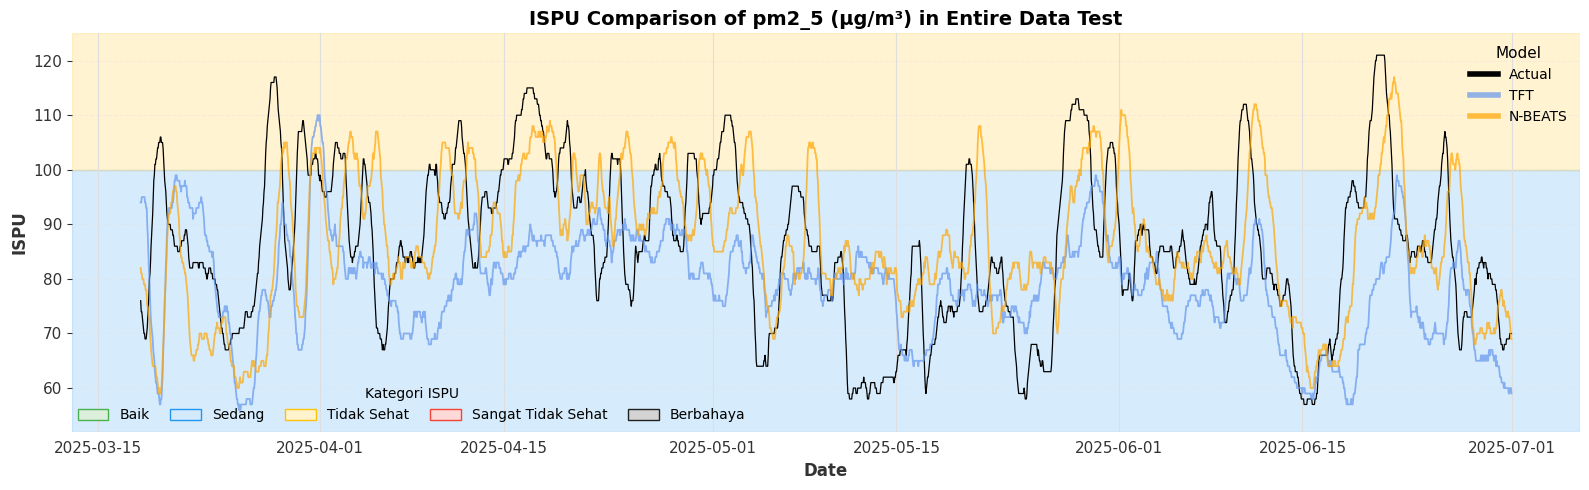

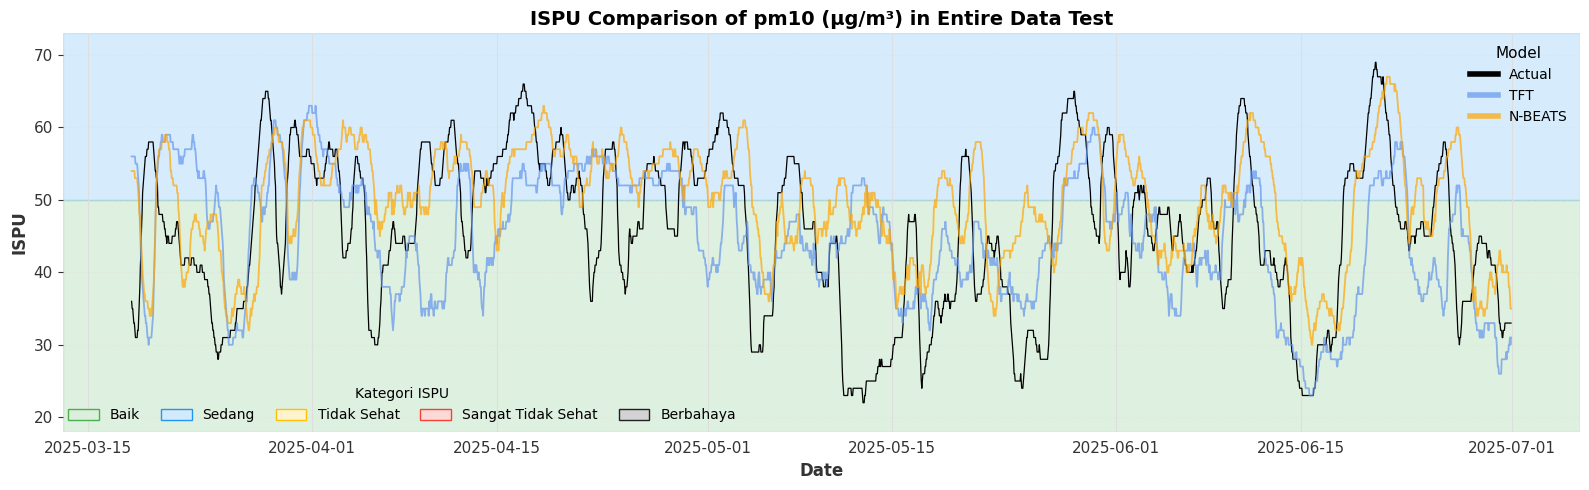

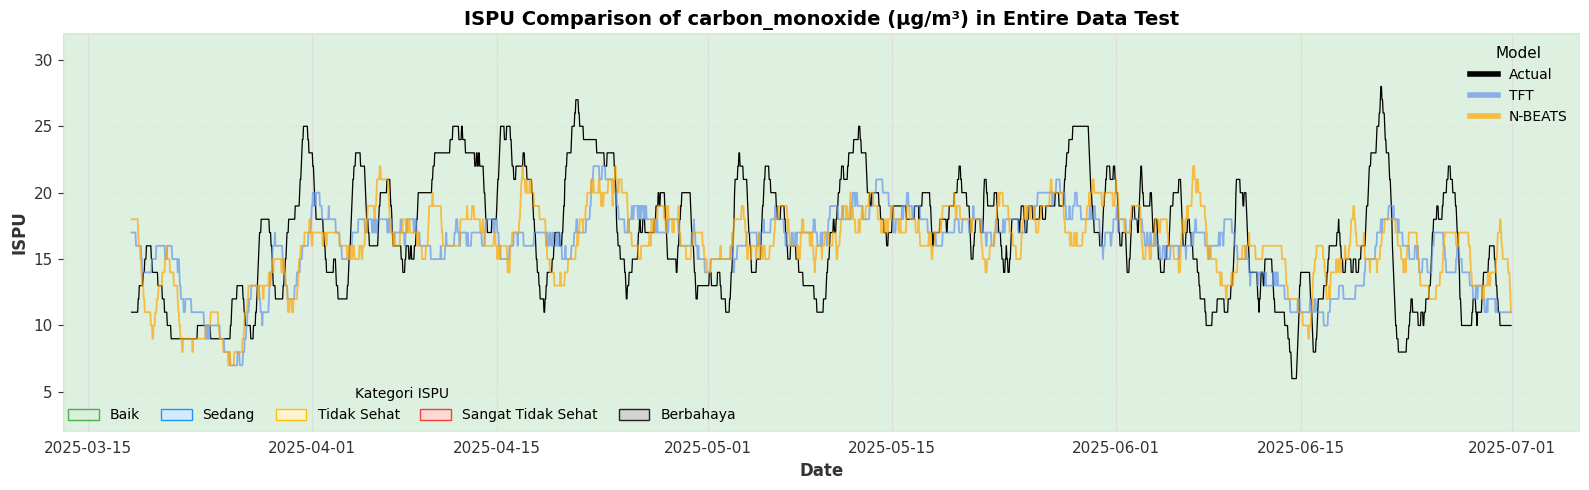

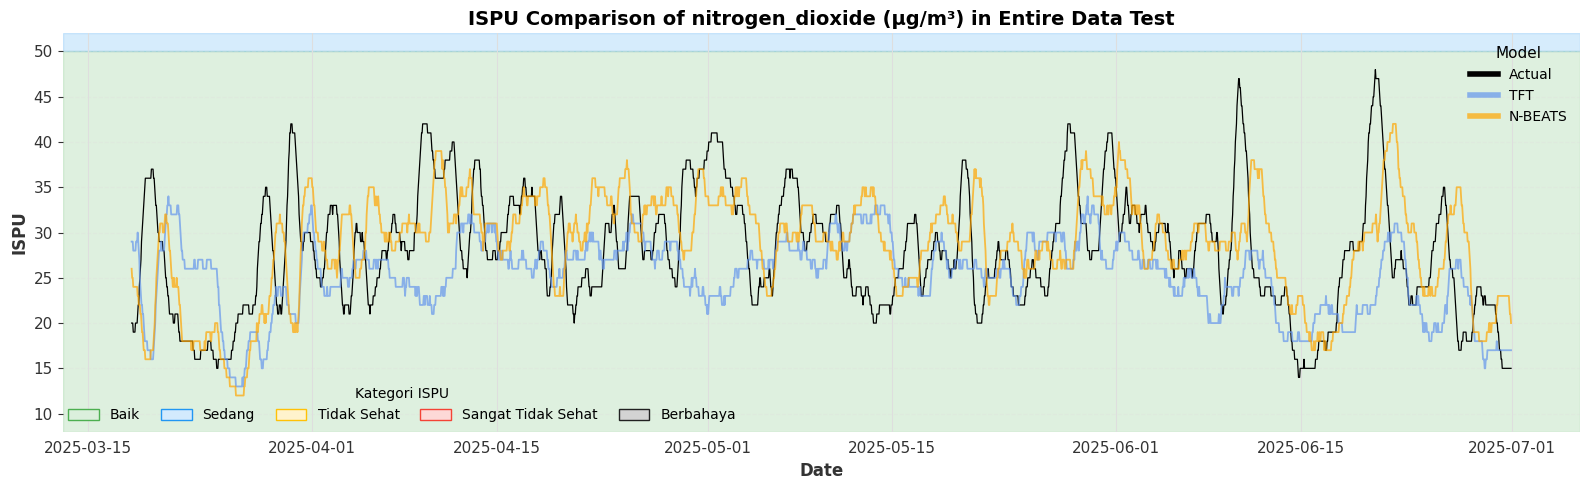

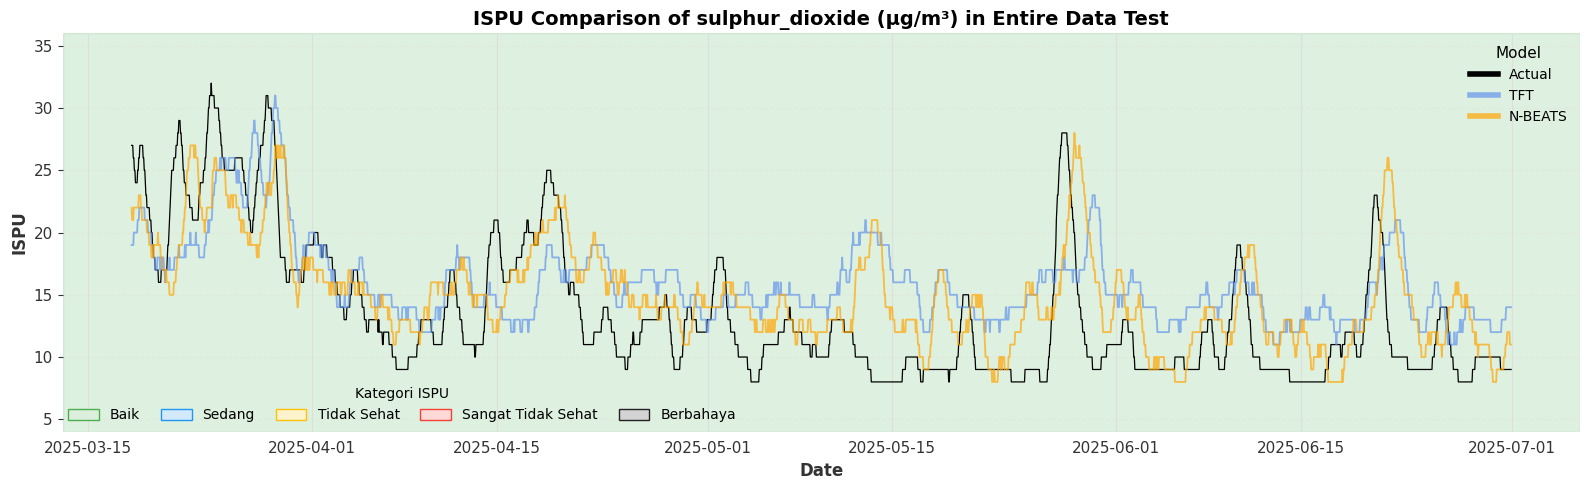

In [15]:
from matplotlib.patches import Patch

# Visualize ISPU results both in actual, TFT, and N-BEATS

# ISPU category ranges
category_ranges = [
    (0,   50,  '#4CAF50', 'Baik'),
    (50,  100, '#2196F3', 'Sedang'),
    (100, 200, '#FFC107', 'Tidak Sehat'),
    (200, 300, '#F44336', 'Sangat Tidak Sehat'),
    (300, 500, '#212121', 'Berbahaya')
]

for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    fig, ax = plt.subplots(figsize=(16, 5))

    # =========================
    # Dynamic y-axis
    # =========================
    min_value = min(
        ispu_df[f'{pollutant}_ispu_actual'].min(),
        ispu_df[f'{pollutant}_ispu_tft_pred'].min(),
        ispu_df[f'{pollutant}_ispu_nbeats_pred'].min()
    )

    max_value = max(
        ispu_df[f'{pollutant}_ispu_actual'].max(),
        ispu_df[f'{pollutant}_ispu_tft_pred'].max(),
        ispu_df[f'{pollutant}_ispu_nbeats_pred'].max()
    )

    data_range = max_value - min_value

    # 3% Margin
    margin = max(data_range * 0.03, 4)
    y_min = max(0, min_value - margin)
    y_max = max_value + margin
    
    ax.set_ylim(y_min, y_max)

    # =========================
    # Background ISPU Category
    # =========================
    for ymin, ymax, color, label in category_ranges:

        if ymax <= y_min:
            continue

        if ymin >= y_max:
            continue

        ax.axhspan(
            max(ymin, y_min),
            min(ymax, y_max),
            color=color,
            alpha=0.18,
            zorder=0
        )

    # =========================
    # Actual
    # =========================
    ax.plot(
        ispu_df.index,
        ispu_df[f'{pollutant}_ispu_actual'],
        label='Actual',
        linewidth=0.9,
        color='black'
    )

    # =========================
    # TFT
    # =========================
    ax.plot(
        ispu_df.index,
        ispu_df[f'{pollutant}_ispu_tft_pred'],
        label='TFT',
        linewidth=1.3,
        alpha=0.7,
        color=color_variant[0]
    )

    # =========================
    # N-BEATS
    # =========================
    ax.plot(
        ispu_df.index,
        ispu_df[f'{pollutant}_ispu_nbeats_pred'],
        label='N-BEATS',
        linewidth=1.3,
        alpha=0.7,
        color=color_variant[1]
    )

    # =========================
    # Figure settings
    # =========================
    ax.set_title(
        f'ISPU Comparison of {col_decode[pollutant]} in Entire Data Test',
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Date',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_ylabel(
        'ISPU',
        fontsize=12,
        fontweight='bold'
    )

    ax.tick_params(
        axis='both',
        labelsize=11
    )

    ax.grid(
        True,
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    # =========================
    # Legend Model
    # =========================
    model_legend = ax.legend(
        title='Model',
        loc='upper right',
        fontsize=10,
        title_fontsize=11,
        frameon=False
    )

    for line in model_legend.get_lines():
        line.set_linewidth(4)

    ax.add_artist(model_legend)

    # =========================
    # Legend Kategori ISPU
    # =========================
    category_handles = [
        Patch(facecolor='#DBEFDC', edgecolor='#4CAF50', linewidth=1, label='Baik'),
        Patch(facecolor='#D3EAFD', edgecolor='#2196F3', linewidth=1, label='Sedang'),
        Patch(facecolor='#FFF3CD', edgecolor='#FFC107', linewidth=1, label='Tidak Sehat'),
        Patch(facecolor='#FDD9D7', edgecolor='#F44336', linewidth=1, label='Sangat Tidak Sehat'),
        Patch(facecolor='#D3D3D3', edgecolor='#212121', linewidth=1, label='Berbahaya')
    ]
    
    ax.legend(
        handles=category_handles,
        title='Kategori ISPU',
        loc='lower left',
        bbox_to_anchor=(0.0, 0.01),
        ncol=5,
        frameon=False,
        fontsize=10,
        title_fontsize=10,
        handlelength=2.2,
        handleheight=0.8,
        columnspacing=1.5,
        borderaxespad=0
    )

    plt.tight_layout()

    plt.savefig(
        f'../reports/figures/ISPU_backtesting_comparison_{pollutant}.png',
        dpi=300
    )

    plt.show()

# ISPU of Future Prediction

In [16]:
# load future prediction results

## ========================= LOAD FUTURE PRED RESULTS ========================= ##
# TFT
tft_future_pred = (
    pd.read_excel('../data/predicted/tft_future_prediction_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)
print('TFT Future Pred Info:')
print(tft_future_pred.info())

# N-BEATS
nbeats_future_pred = (
    pd.read_excel('../data/predicted/nbeats_future_prediction_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)
print('\nN-BEATS Future Pred Info:')
print(nbeats_future_pred.info())

TFT Future Pred Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 2025-07-01 00:00:00 to 2025-07-01 11:00:00
Freq: h
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   y1_future_pred  12 non-null     float64
 1   y2_future_pred  12 non-null     float64
 2   y3_future_pred  12 non-null     float64
 3   y4_future_pred  12 non-null     float64
 4   y5_future_pred  12 non-null     float64
dtypes: float64(5)
memory usage: 576.0 bytes
None

N-BEATS Future Pred Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 2025-07-01 00:00:00 to 2025-07-01 11:00:00
Freq: h
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   y1_future_pred  12 non-null     float64
 1   y2_future_pred  12 non-null     float64
 2   y3_future_pred  12 non-null     float64
 3   y4_future_pred  12 non-null     float64
 4   y5_future_pred 

In [17]:
# Merge last 24 data from bactesting with TFT future pred
tft_future_rolling = (
    pd.concat([
        tft_backtesting.loc[
            '2025-06-30 01:00':'2025-06-30 23:00',
            ['y1_pred', 'y2_pred', 'y3_pred', 'y4_pred', 'y5_pred']
        ],

        tft_future_pred.rename(
            columns=lambda x:
            x.replace('_future_pred', '_pred')
        )
    ])
    .rolling(window=24)
    .mean()
    .loc['2025-07-01 00:00':'2025-07-01 11:00']
)

# Check
print(tft_future_rolling.info())
pd.concat([
    tft_future_rolling.head(5),
    pd.DataFrame(index=['...']),
    tft_future_rolling.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 2025-07-01 00:00:00 to 2025-07-01 11:00:00
Freq: h
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   y1_pred  12 non-null     float64
 1   y2_pred  12 non-null     float64
 2   y3_pred  12 non-null     float64
 3   y4_pred  12 non-null     float64
 4   y5_pred  12 non-null     float64
dtypes: float64(5)
memory usage: 576.0 bytes
None


,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred
2025-07-01 00:00:00,22.516129,30.836455,886.689629,26.933728,14.290514
2025-07-01 01:00:00,22.467078,30.754169,885.959246,26.530081,14.394952
2025-07-01 02:00:00,22.684333,31.367488,910.884092,26.279441,14.620016
2025-07-01 03:00:00,22.623042,30.864629,904.183612,26.085914,15.018117
2025-07-01 04:00:00,22.196410,30.631018,900.748690,25.568016,15.321483
...,NaN,NaN,NaN,NaN,NaN
2025-07-01 11:00:00,19.822754,27.736079,731.531718,20.490727,15.822480


In [18]:
# Merge last 24 data from bactesting with N-BEATS future pred
nbeats_future_rolling = (
    pd.concat([
        nbeats_backtesting.loc[
            '2025-06-30 01:00':'2025-06-30 23:00',
            ['y1_pred', 'y2_pred', 'y3_pred', 'y4_pred', 'y5_pred']
        ],

        nbeats_future_pred.rename(
            columns=lambda x:
            x.replace('_future_pred', '_pred')
        )
    ])
    .rolling(window=24)
    .mean()
    .loc['2025-07-01 00:00':'2025-07-01 11:00']
)

# Check
print(nbeats_future_rolling.info())
pd.concat([
    nbeats_future_rolling.head(5),
    pd.DataFrame(index=['...']),
    nbeats_future_rolling.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 2025-07-01 00:00:00 to 2025-07-01 11:00:00
Freq: h
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   y1_pred  12 non-null     float64
 1   y2_pred  12 non-null     float64
 2   y3_pred  12 non-null     float64
 3   y4_pred  12 non-null     float64
 4   y5_pred  12 non-null     float64
dtypes: float64(5)
memory usage: 576.0 bytes
None


,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred
2025-07-01 00:00:00,28.313255,34.085531,866.704763,30.312617,11.641834
2025-07-01 01:00:00,27.463332,31.949031,828.917455,29.158006,11.745670
2025-07-01 02:00:00,25.932369,30.441683,792.162382,28.275380,11.771821
2025-07-01 03:00:00,24.690730,29.062717,703.619831,27.181983,11.954439
2025-07-01 04:00:00,23.009585,27.778758,663.716104,25.946758,11.848728
...,NaN,NaN,NaN,NaN,NaN
2025-07-01 11:00:00,21.428624,28.127892,744.332444,22.136441,10.851979


In [19]:
# Calculate Actual and TFT Backtesting Results
for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    # Calculate ISPU for TFT future pred results
    tft_future_rolling[f'{pollutant}_ispu_tft_pred'] = (
        tft_future_rolling[f'{pollutant}_pred']
        .apply(lambda x:
              calculate_ispu(x, breakpoints[pollutant])
        )
    )

    # Calculate ISPU for N-BEATS future pred results
    nbeats_future_rolling[f'{pollutant}_ispu_nbeats_pred'] = (
        nbeats_future_rolling[f'{pollutant}_pred']
        .apply(lambda x:
              calculate_ispu(x, breakpoints[pollutant])
        )
    )

In [20]:
# Check
print(tft_future_rolling.info())
pd.concat([
    tft_future_rolling.head(5),
    pd.DataFrame(index=['...']),
    tft_future_rolling.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 2025-07-01 00:00:00 to 2025-07-01 11:00:00
Freq: h
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   y1_pred           12 non-null     float64
 1   y2_pred           12 non-null     float64
 2   y3_pred           12 non-null     float64
 3   y4_pred           12 non-null     float64
 4   y5_pred           12 non-null     float64
 5   y1_ispu_tft_pred  12 non-null     int64  
 6   y2_ispu_tft_pred  12 non-null     int64  
 7   y3_ispu_tft_pred  12 non-null     int64  
 8   y4_ispu_tft_pred  12 non-null     int64  
 9   y5_ispu_tft_pred  12 non-null     int64  
dtypes: float64(5), int64(5)
memory usage: 1.0 KB
None


,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred,y1_ispu_tft_pred,y2_ispu_tft_pred,y3_ispu_tft_pred,y4_ispu_tft_pred,y5_ispu_tft_pred
2025-07-01 00:00:00,22.516129,30.836455,886.689629,26.933728,14.290514,60.0,31.0,11.0,17.0,14.0
2025-07-01 01:00:00,22.467078,30.754169,885.959246,26.530081,14.394952,60.0,31.0,11.0,17.0,14.0
2025-07-01 02:00:00,22.684333,31.367488,910.884092,26.279441,14.620016,60.0,31.0,11.0,16.0,14.0
2025-07-01 03:00:00,22.623042,30.864629,904.183612,26.085914,15.018117,60.0,31.0,11.0,16.0,14.0
2025-07-01 04:00:00,22.196410,30.631018,900.748690,25.568016,15.321483,59.0,31.0,11.0,16.0,15.0
...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-01 11:00:00,19.822754,27.736079,731.531718,20.490727,15.822480,56.0,28.0,9.0,13.0,15.0


In [21]:
# Check
print(nbeats_future_rolling.info())
pd.concat([
    nbeats_future_rolling.head(5),
    pd.DataFrame(index=['...']),
    nbeats_future_rolling.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 2025-07-01 00:00:00 to 2025-07-01 11:00:00
Freq: h
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   y1_pred              12 non-null     float64
 1   y2_pred              12 non-null     float64
 2   y3_pred              12 non-null     float64
 3   y4_pred              12 non-null     float64
 4   y5_pred              12 non-null     float64
 5   y1_ispu_nbeats_pred  12 non-null     int64  
 6   y2_ispu_nbeats_pred  12 non-null     int64  
 7   y3_ispu_nbeats_pred  12 non-null     int64  
 8   y4_ispu_nbeats_pred  12 non-null     int64  
 9   y5_ispu_nbeats_pred  12 non-null     int64  
dtypes: float64(5), int64(5)
memory usage: 1.0 KB
None


,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred,y1_ispu_nbeats_pred,y2_ispu_nbeats_pred,y3_ispu_nbeats_pred,y4_ispu_nbeats_pred,y5_ispu_nbeats_pred
2025-07-01 00:00:00,28.313255,34.085531,866.704763,30.312617,11.641834,67.0,34.0,11.0,19.0,11.0
2025-07-01 01:00:00,27.463332,31.949031,828.917455,29.158006,11.745670,66.0,32.0,10.0,18.0,11.0
2025-07-01 02:00:00,25.932369,30.441683,792.162382,28.275380,11.771821,64.0,30.0,10.0,18.0,11.0
2025-07-01 03:00:00,24.690730,29.062717,703.619831,27.181983,11.954439,62.0,29.0,9.0,17.0,11.0
2025-07-01 04:00:00,23.009585,27.778758,663.716104,25.946758,11.848728,60.0,28.0,8.0,16.0,11.0
...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-01 11:00:00,21.428624,28.127892,744.332444,22.136441,10.851979,58.0,28.0,9.0,14.0,10.0


In [22]:
# Calculate ISPU for Future Prediction

# Merge future ISPU
future_ispu_df = pd.DataFrame({'t': tft_future_rolling.index}).set_index('t').sort_index()

pollutants = ['y1', 'y2', 'y3', 'y4', 'y5']

# Calculate ISPU
for pollutant in pollutants:

    # TFT
    future_ispu_df[f'{pollutant}_ispu_tft_pred'] = tft_future_rolling[f'{pollutant}_ispu_tft_pred'].values

    # N-BEATS
    future_ispu_df[f'{pollutant}_ispu_nbeats_pred'] = nbeats_future_rolling[f'{pollutant}_ispu_nbeats_pred'].values


# Add ISPU Categories
for pollutant in pollutants:

    # TFT
    future_ispu_df[f'{pollutant}_category_ispu_tft_pred'] = future_ispu_df[f'{pollutant}_ispu_tft_pred'].apply(ispu_category)

    # N-BEATS
    future_ispu_df[f'{pollutant}_category_ispu_nbeats_pred'] = future_ispu_df[f'{pollutant}_ispu_nbeats_pred'].apply(ispu_category)

# Save results
future_ispu_df.to_excel('../reports/ispu_future.xlsx')

# Check results
print(future_ispu_df.info())
pd.concat([
    future_ispu_df.head(5),
    pd.DataFrame(index=['...']),
    future_ispu_df.tail(1)
])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 2025-07-01 00:00:00 to 2025-07-01 11:00:00
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   y1_ispu_tft_pred              12 non-null     int64 
 1   y1_ispu_nbeats_pred           12 non-null     int64 
 2   y2_ispu_tft_pred              12 non-null     int64 
 3   y2_ispu_nbeats_pred           12 non-null     int64 
 4   y3_ispu_tft_pred              12 non-null     int64 
 5   y3_ispu_nbeats_pred           12 non-null     int64 
 6   y4_ispu_tft_pred              12 non-null     int64 
 7   y4_ispu_nbeats_pred           12 non-null     int64 
 8   y5_ispu_tft_pred              12 non-null     int64 
 9   y5_ispu_nbeats_pred           12 non-null     int64 
 10  y1_category_ispu_tft_pred     12 non-null     object
 11  y1_category_ispu_nbeats_pred  12 non-null     object
 12  y2_category_ispu_tft_pred     12 non-null 

,y1_ispu_tft_pred,y1_ispu_nbeats_pred,y2_ispu_tft_pred,y2_ispu_nbeats_pred,y3_ispu_tft_pred,y3_ispu_nbeats_pred,y4_ispu_tft_pred,y4_ispu_nbeats_pred,y5_ispu_tft_pred,y5_ispu_nbeats_pred,y1_category_ispu_tft_pred,y1_category_ispu_nbeats_pred,y2_category_ispu_tft_pred,y2_category_ispu_nbeats_pred,y3_category_ispu_tft_pred,y3_category_ispu_nbeats_pred,y4_category_ispu_tft_pred,y4_category_ispu_nbeats_pred,y5_category_ispu_tft_pred,y5_category_ispu_nbeats_pred
2025-07-01 00:00:00,60.0,67.0,31.0,34.0,11.0,11.0,17.0,19.0,14.0,11.0,Sedang,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-07-01 01:00:00,60.0,66.0,31.0,32.0,11.0,10.0,17.0,18.0,14.0,11.0,Sedang,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-07-01 02:00:00,60.0,64.0,31.0,30.0,11.0,10.0,16.0,18.0,14.0,11.0,Sedang,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-07-01 03:00:00,60.0,62.0,31.0,29.0,11.0,9.0,16.0,17.0,14.0,11.0,Sedang,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-07-01 04:00:00,59.0,60.0,31.0,28.0,11.0,8.0,16.0,16.0,15.0,11.0,Sedang,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-01 11:00:00,56.0,58.0,28.0,28.0,9.0,9.0,13.0,14.0,15.0,10.0,Sedang,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik


# Visualize ISPU of Future Prediction

In [23]:
# # Visualize ISPU results both in actual, TFT, and N-BEATS
# thresholds = [50, 100, 200, 300]
# threshold_labels = {
#     50: 'Baik',
#     100: 'Sedang',
#     200: 'Tidak Sehat',
#     300: 'Sangat Tidak Sehat'
# }

# for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:
#     fig, ax = plt.subplots(figsize=(16, 5))

#     # TFT
#     ax.plot(future_ispu_df.index, future_ispu_df[f'{pollutant}_ispu_tft_pred'], label='TFT', linewidth=2, alpha=0.9, color=color_variant[0])

#     # N-BEATS
#     ax.plot(future_ispu_df.index, future_ispu_df[f'{pollutant}_ispu_nbeats_pred'], label='N-BEATS', linewidth=2, alpha=0.9, color=color_variant[1])

    
#     # ISPU thresholds
#     max_value = max(
#         future_ispu_df[f'{pollutant}_ispu_tft_pred'].max(),
#         future_ispu_df[f'{pollutant}_ispu_nbeats_pred'].max()
#     )
    
#     for threshold in thresholds:
#         if threshold <= max_value:
#             ax.axhline(threshold, linestyle='--', alpha=0.5, color=color_variant[9])
#             ax.text(future_ispu_df.index[-1], threshold, threshold_labels[threshold], fontsize=11, va='top', ha='right'
#         )

#     ax.set_title(f'ISPU Comparison of {col_decode[pollutant]} in Future Prediction', fontsize=14, fontweight='bold')
#     ax.set_xlabel('Date', fontsize=12, fontweight='bold')
#     ax.set_ylabel('ISPU', fontsize=12, fontweight='bold')
#     ax.legend()
#     ax.grid(True, axis='x')
#     plt.tight_layout()
#     plt.savefig(f'../reports/figures/ISPU_future_comparison_{pollutant}.png', dpi=300)
#     plt.show()

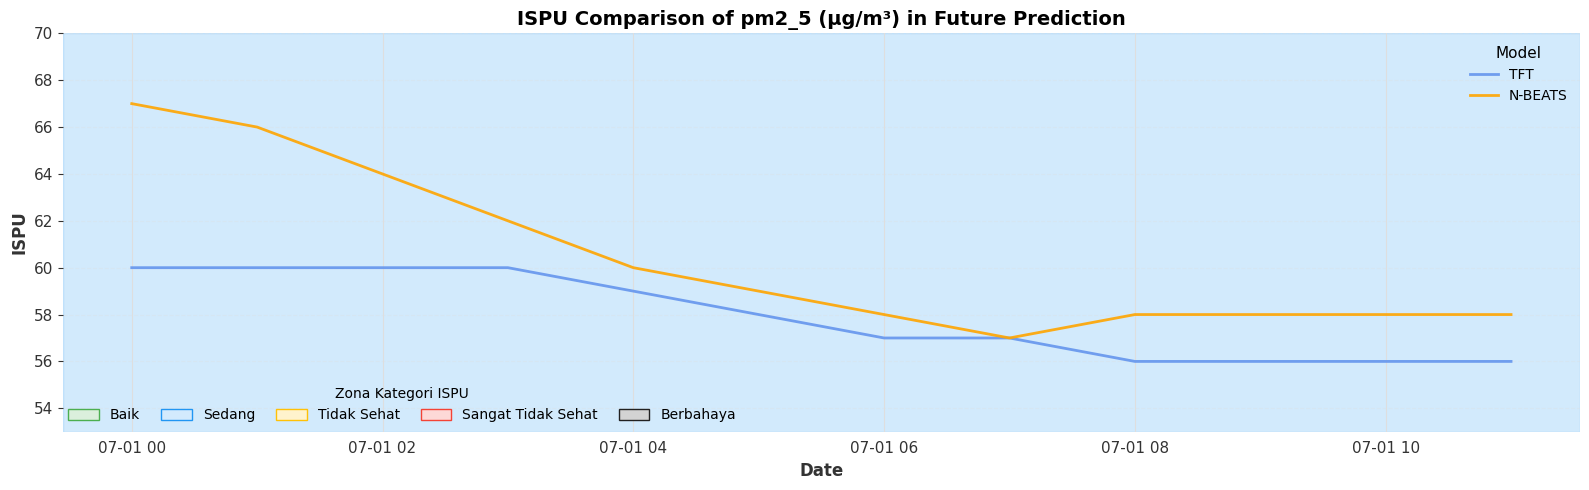

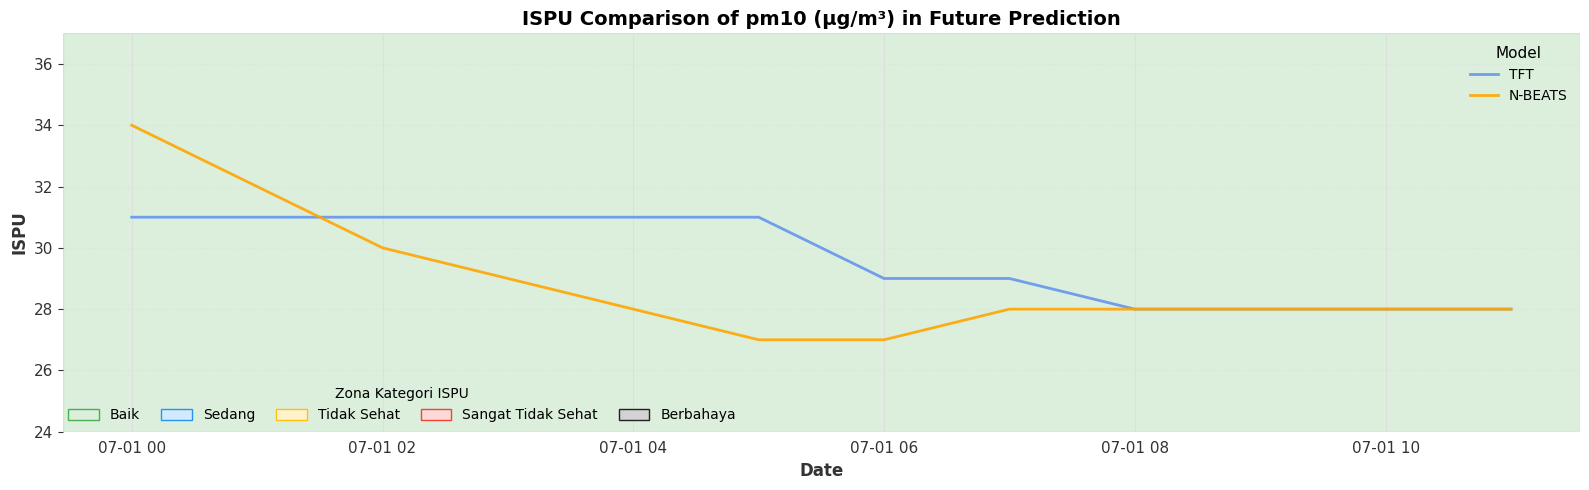

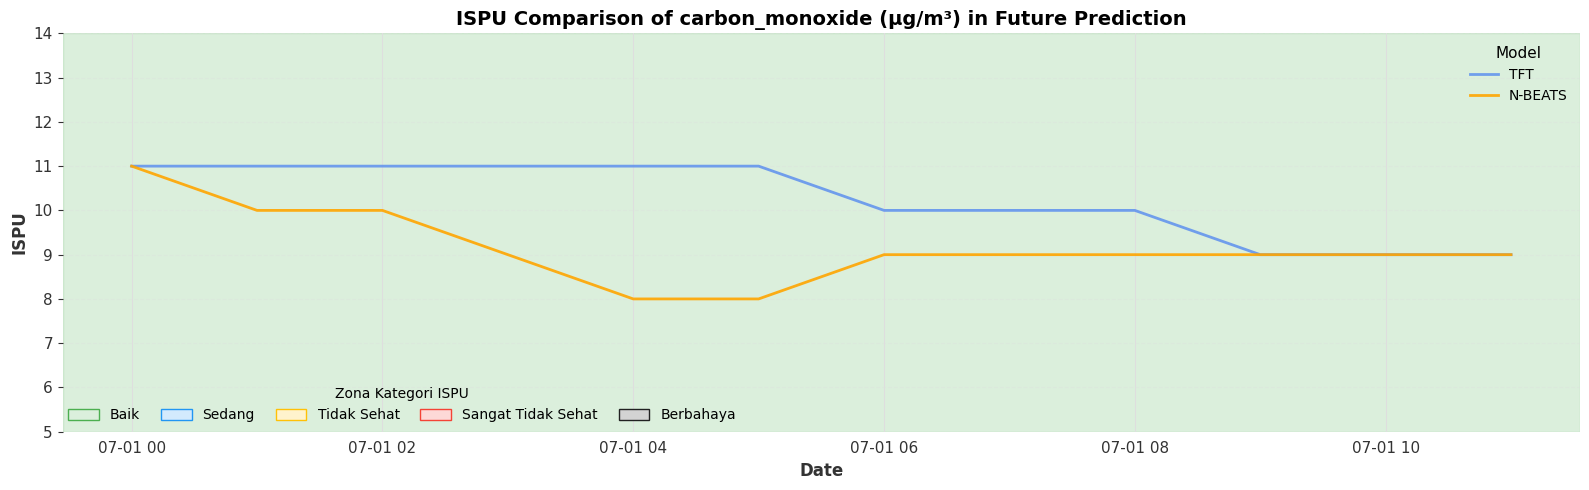

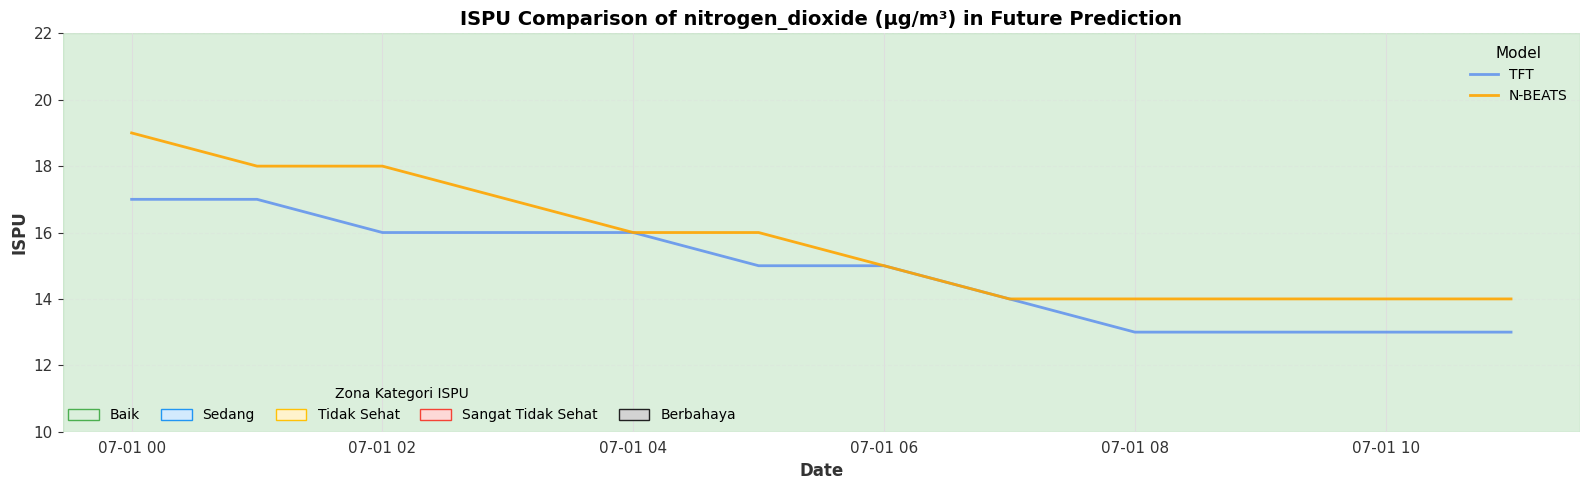

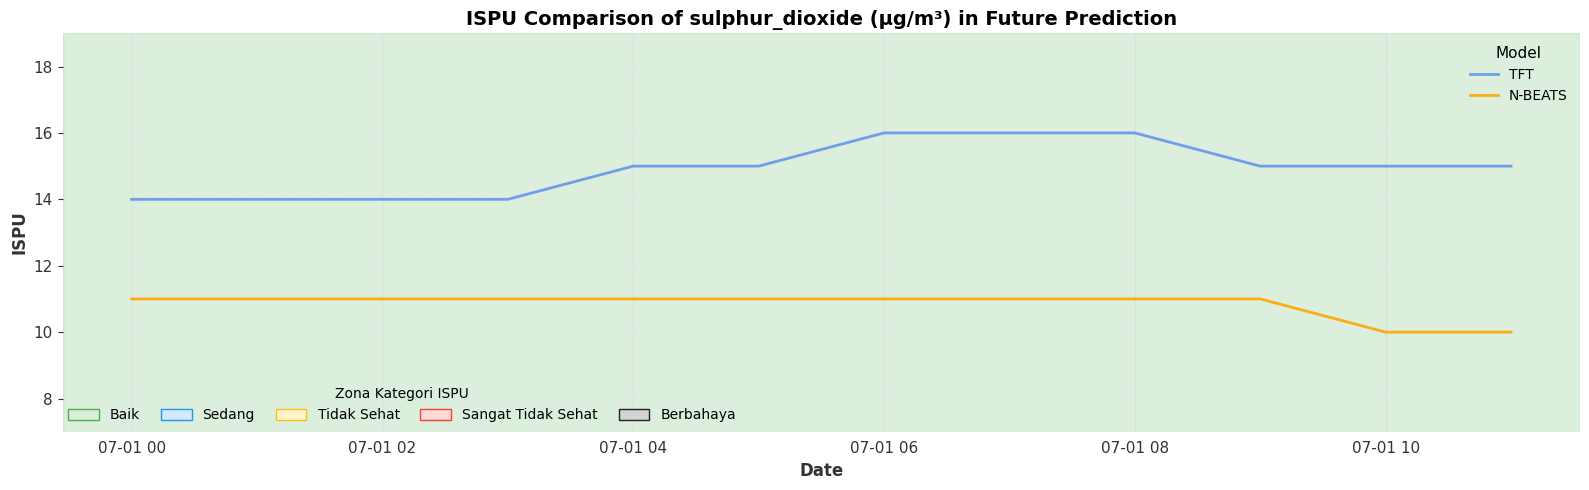

In [24]:
from matplotlib.patches import Patch

# Visualize Future ISPU Prediction (TFT vs N-BEATS)

# ISPU category ranges
category_ranges = [
    (0,   50,  '#4CAF50', 'Baik'),
    (50,  100, '#2196F3', 'Sedang'),
    (100, 200, '#FFC107', 'Tidak Sehat'),
    (200, 300, '#F44336', 'Sangat Tidak Sehat'),
    (300, 500, '#212121', 'Berbahaya')
]

for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    fig, ax = plt.subplots(figsize=(16, 5))

    # =========================
    # Dynamic y-axis (zoom)
    # =========================
    min_value = min(
        future_ispu_df[f'{pollutant}_ispu_tft_pred'].min(),
        future_ispu_df[f'{pollutant}_ispu_nbeats_pred'].min()
    )

    max_value = max(
        future_ispu_df[f'{pollutant}_ispu_tft_pred'].max(),
        future_ispu_df[f'{pollutant}_ispu_nbeats_pred'].max()
    )

    data_range = max_value - min_value
    margin = max(data_range * 0.03, 3)

    y_min = max(0, min_value - margin)
    y_max = max_value + margin

    ax.set_ylim(y_min, y_max)

    # =========================
    # Background kategori ISPU
    # =========================
    for ymin, ymax, color, label in category_ranges:

        if ymax <= y_min:
            continue

        if ymin >= y_max:
            continue

        ax.axhspan(
            max(ymin, y_min),
            min(ymax, y_max),
            color=color,
            alpha=0.2,
            zorder=0
        )

    # =========================
    # TFT
    # =========================
    ax.plot(
        future_ispu_df.index,
        future_ispu_df[f'{pollutant}_ispu_tft_pred'],
        label='TFT',
        linewidth=2,
        alpha=0.9,
        color=color_variant[0]
    )

    # =========================
    # N-BEATS
    # =========================
    ax.plot(
        future_ispu_df.index,
        future_ispu_df[f'{pollutant}_ispu_nbeats_pred'],
        label='N-BEATS',
        linewidth=2,
        alpha=0.9,
        color=color_variant[1]
    )

    # =========================
    # Figure settings
    # =========================
    ax.set_title(
        f'ISPU Comparison of {col_decode[pollutant]} in Future Prediction',
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Date',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_ylabel(
        'ISPU',
        fontsize=12,
        fontweight='bold'
    )

    ax.tick_params(
        axis='both',
        labelsize=11
    )

    ax.grid(
        True,
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    # =========================
    # Legend Model
    # =========================
    model_legend = ax.legend(
        title='Model',
        loc='upper right',
        fontsize=10,
        title_fontsize=11,
        frameon=False
    )

    ax.add_artist(model_legend)

    # =========================
    # Legend Kategori ISPU
    # =========================
    category_handles = [
        Patch(facecolor='#DBEFDC', edgecolor='#4CAF50', linewidth=1, label='Baik'),
        Patch(facecolor='#D3EAFD', edgecolor='#2196F3', linewidth=1, label='Sedang'),
        Patch(facecolor='#FFF3CD', edgecolor='#FFC107', linewidth=1, label='Tidak Sehat'),
        Patch(facecolor='#FDD9D7', edgecolor='#F44336', linewidth=1, label='Sangat Tidak Sehat'),
        Patch(facecolor='#D3D3D3', edgecolor='#212121', linewidth=1, label='Berbahaya')
    ]

    ax.legend(
        handles=category_handles,
        title='Zona Kategori ISPU',
        loc='lower left',
        bbox_to_anchor=(0.0, 0.01),
        ncol=5,
        frameon=False,
        fontsize=10,
        title_fontsize=10,
        handlelength=2.2,
        handleheight=0.8,
        columnspacing=1.5,
        borderaxespad=0
    )

    plt.tight_layout()

    plt.savefig(
        f'../reports/figures/ISPU_future_comparison_{pollutant}.png',
        dpi=300
    )

    plt.show()

# Evaluation

In [25]:
# Evaluate ISPU Backtesting Results
evaluation_results = []

pollutants = ['y1', 'y2', 'y3', 'y4', 'y5']

for pollutant in pollutants:

    # ========================= TFT ========================= #
    actual = ispu_df[f'{pollutant}_ispu_actual']

    tft_pred = ispu_df[f'{pollutant}_ispu_tft_pred']

    evaluation_results.append({
        'pollutant': col_decode[pollutant],
        'model': 'TFT',
        'MAE': mean_absolute_error(
            actual,
            tft_pred
        ),
        'MAPE (%)': mean_absolute_percentage_error(
            actual,
            tft_pred
        ) * 100,
        'RMSE': root_mean_squared_error(
            actual,
            tft_pred
        ),
    })

    # ====================== N-BEATS ======================= #
    nbeats_pred = ispu_df[f'{pollutant}_ispu_nbeats_pred']

    evaluation_results.append({
        'pollutant': col_decode[pollutant],
        'model': 'N-BEATS',
        'MAE': mean_absolute_error(
            actual,
            nbeats_pred
        ),
        'MAPE (%)': mean_absolute_percentage_error(
            actual,
            nbeats_pred
        ) * 100,
        'RMSE': root_mean_squared_error(
            actual,
            nbeats_pred
        ),
    })


# Convert to dataframe
evaluation_df = pd.DataFrame(evaluation_results)

# Check
evaluation_df

,pollutant,model,MAE,MAPE (%),RMSE
0,pm2_5 (μg/m³),TFT,13.127338,14.724884,16.387141
1,pm2_5 (μg/m³),N-BEATS,11.628731,13.895131,14.507583
2,pm10 (μg/m³),TFT,9.014326,21.455614,11.048153
3,pm10 (μg/m³),N-BEATS,8.542778,22.325149,10.708302
4,carbon_monoxide (μg/m³),TFT,3.150020,19.831080,3.908626
5,carbon_monoxide (μg/m³),N-BEATS,3.222841,20.422912,4.036099
6,nitrogen_dioxide (μg/m³),TFT,5.898528,20.483419,7.722943
7,nitrogen_dioxide (μg/m³),N-BEATS,5.345006,19.849796,6.825259
8,sulphur_dioxide (μg/m³),TFT,4.195384,37.362922,4.986851
9,sulphur_dioxide (μg/m³),N-BEATS,3.372463,28.695950,4.338401


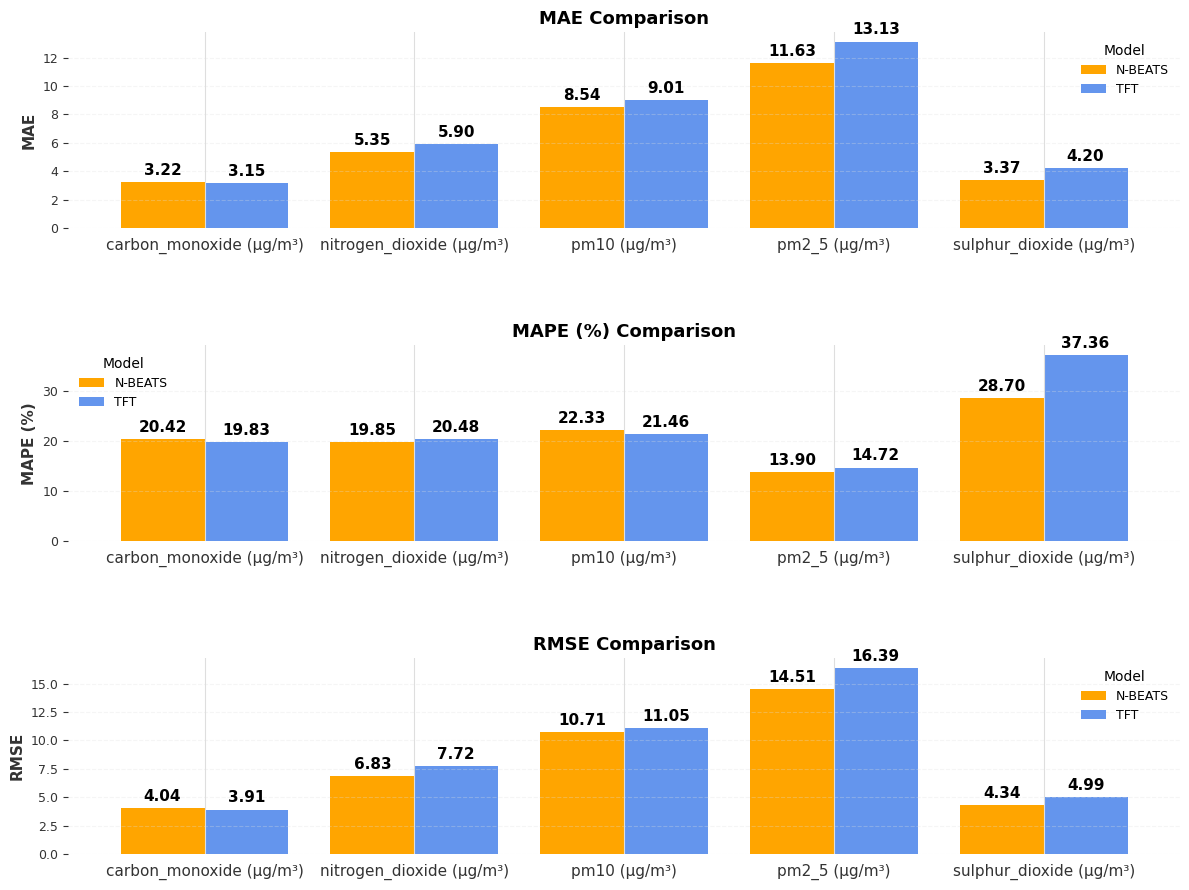

In [26]:
metrics = ['MAE', 'MAPE (%)', 'RMSE']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 9))

for ax, metric in zip(axes, metrics):

    pivot_df = evaluation_df.pivot(index='pollutant', columns='model', values=metric)

    pivot_df.plot(kind='bar', ax=ax, rot=0, width=0.8, color=[color_variant[1], color_variant[0]])

    # Add value labels
    for container in ax.containers:

        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, fontweight='bold')

    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=0, labelsize=11)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.legend(title='Model', fontsize=9, title_fontsize=10, frameon=False)
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.savefig('../reports/figures/ispu_evaluation_metrics.png', dpi=300)
plt.show()